# Radial Velocity Analysis of 55 Cancri (HD 75732)
## Exoplanet Detection via the Doppler Spectroscopy Method

**Author:** Jeremy Joseph

**Date:** 2026

**Data Source:** NASA Exoplanet Archive — Howard & Fulton (2016), Lick Observatory (3.0m Shane Telescope, Hamilton Spectrograph)


## Step 1: Import Libraries and Load Data

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3
})

print('Libraries imported successfully.')

Libraries imported successfully.


In [14]:
# ── Load the NASA Exoplanet Archive RV data for 55 Cnc ──────────────────────

data = np.genfromtxt(
    'rv.txt',
    comments='\\',   # skip metadata lines
    invalid_raise=False
)

# Remove any rows that contain NaN (header separator rows)
data = data[~np.isnan(data).any(axis=1)]

hjd  = data[:, 0]   # Heliocentric Julian Date (days)
rv   = data[:, 1]   # Radial velocity (m/s)
rv_err = data[:, 2] # RV uncertainty (m/s)

# Convert HJD to years from first observation for readability
t0   = hjd[0]
time = (hjd - t0)  

print(f'Loaded {len(rv)} data points.')
print(f'Time baseline: {time[-1]:.1f} days ({time[-1]/365.25:.1f} years)')
print(f'RV range: {rv.min():.1f} to {rv.max():.1f} m/s')

Loaded 274 data points.
Time baseline: 5927.7 days (16.2 years)
RV range: -130.6 to 141.5 m/s


/var/folders/xt/_8lz_wtd5kd1xtqqb7lp5q980000gn/T/ipykernel_77851/1192376455.py:3: ConversionWarning: Some errors were detected !
    Line #2 (got 4 columns instead of 3)
    Line #3 (got 8 columns instead of 3)
    Line #4 (got 4 columns instead of 3)
  data = np.genfromtxt(


## Step 2: Plot Radial Velocity vs. Time

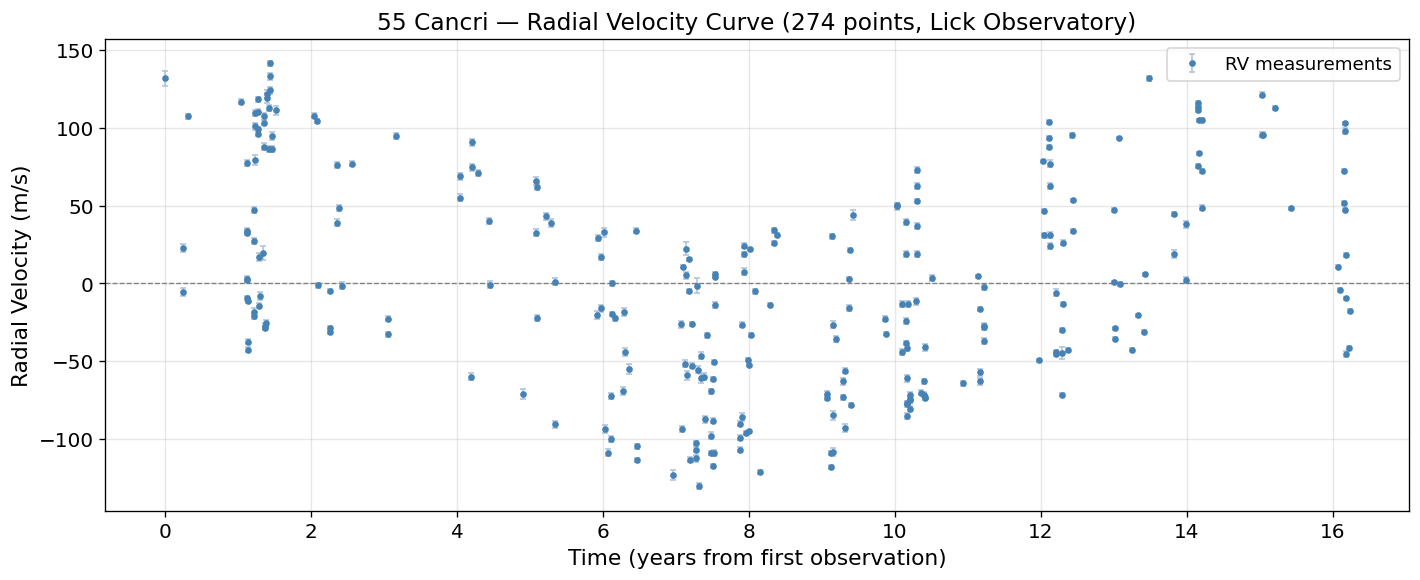

Figure saved as rv_raw.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.errorbar(
    time / 365.25, rv, yerr=rv_err,
    fmt='o', markersize=3, color='steelblue',
    ecolor='lightsteelblue', elinewidth=1, capsize=2,
    label='RV measurements'
)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Time (years from first observation)')
ax.set_ylabel('Radial Velocity (m/s)')
ax.set_title('55 Cancri — Radial Velocity Curve (274 points, Lick Observatory)')
ax.legend()
plt.tight_layout()
plt.savefig('rv_raw.png', bbox_inches='tight')
plt.show()
print('Figure saved as rv_raw.png')

## Step 3: Oscillatory Model

In [16]:
def rv_model(t, K, P, t_phi, v0):
    """Single-planet circular-orbit RV model.
    t     : time array (days)
    K     : semi-amplitude (m/s)
    P     : orbital period (days)
    t_phi : phase offset (days)
    v0    : systemic velocity offset (m/s)
    """
    return K * np.sin(2 * np.pi / P * (t - t_phi)) + v0


# ── Initial parameter guesses ────────────────────────────────────────────────
K0    = 70.0    # m/s  — semi-amplitude
P0    = 14.65   # days — orbital period (55 Cnc b is ~14.65 days)
phi0  = 5.0     # days — phase offset
v0_0  = 0.0     # m/s  — systemic offset

p0 = [K0, P0, phi0, v0_0]

popt, pcov = curve_fit(
    rv_model,
    time,           
    rv,             
    p0=p0,
    sigma=rv_err,   
    absolute_sigma=True,
    maxfev=10000
)

perr = np.sqrt(np.diag(pcov))   

K_fit, P_fit, phi_fit, v0_fit = popt
K_err, P_err, phi_err, v0_err = perr

print('Best-fit parameters:')
print(f'  Semi-amplitude K  = {K_fit:.3f} ± {K_err:.3f} m/s')
print(f'  Period         P  = {P_fit:.4f} ± {P_err:.4f} days')
print(f'  Phase offset   t_phi = {phi_fit:.3f} ± {phi_err:.3f} days')
print(f'  Velocity offset v0 = {v0_fit:.3f} ± {v0_err:.3f} m/s')

Best-fit parameters:
  Semi-amplitude K  = -74.494 ± 0.129 m/s
  Period         P  = 14.6515 ± 0.0000 days
  Phase offset   t_phi = 2.919 ± 0.010 days
  Velocity offset v0 = 4.556 ± 0.093 m/s


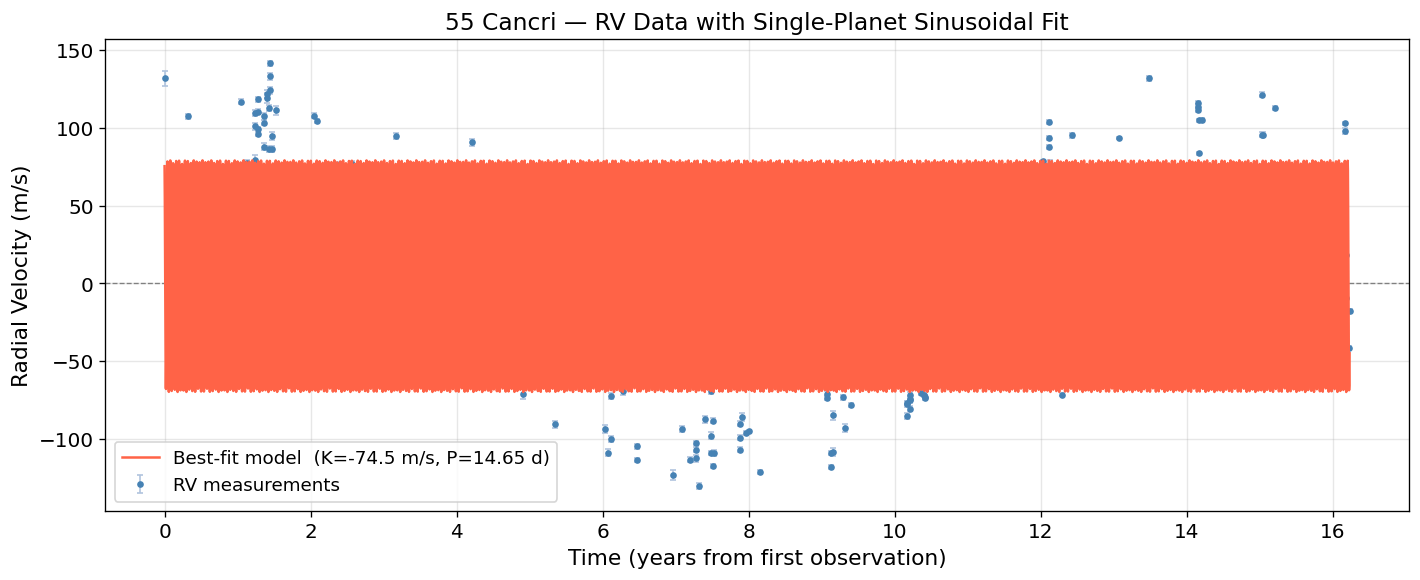

Figure saved as rv_fit.png


In [17]:
# ── Plot data + best-fit model ───────────────────────────────────────────────
t_smooth = np.linspace(time.min(), time.max(), 5000)
rv_fit   = rv_model(t_smooth, *popt)

fig, ax = plt.subplots(figsize=(12, 5))

ax.errorbar(
    time / 365.25, rv, yerr=rv_err,
    fmt='o', markersize=3, color='steelblue',
    ecolor='lightsteelblue', elinewidth=1, capsize=2,
    label='RV measurements',
    zorder=2
)
ax.plot(
    t_smooth / 365.25, rv_fit,
    color='tomato', linewidth=1.5,
    label=f'Best-fit model  (K={K_fit:.1f} m/s, P={P_fit:.2f} d)',
    zorder=3
)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Time (years from first observation)')
ax.set_ylabel('Radial Velocity (m/s)')
ax.set_title('55 Cancri — RV Data with Single-Planet Sinusoidal Fit')
ax.legend()
plt.tight_layout()
plt.savefig('rv_fit.png', bbox_inches='tight')
plt.show()
print('Figure saved as rv_fit.png')

## Step 4: Residuals Analysis

In [18]:
# ── Compute residuals ────────────────────────────────────────────────────────
rv_model_at_data = rv_model(time, *popt)
residuals = rv - rv_model_at_data

residual_std  = np.std(residuals)
residual_mean = np.mean(residuals)
mean_err      = np.mean(rv_err)

print(f'Residuals:')
print(f'  Mean              = {residual_mean:.3f} m/s  (should be ~0)')
print(f'  Std dev (scatter) = {residual_std:.3f} m/s')
print(f'  Mean obs. error   = {mean_err:.3f} m/s')
print(f'  Ratio (scatter / obs. error) = {residual_std / mean_err:.2f}')
print()

Residuals:
  Mean              = -2.419 m/s  (should be ~0)
  Std dev (scatter) = 36.932 m/s
  Mean obs. error   = 1.806 m/s
  Ratio (scatter / obs. error) = 20.45



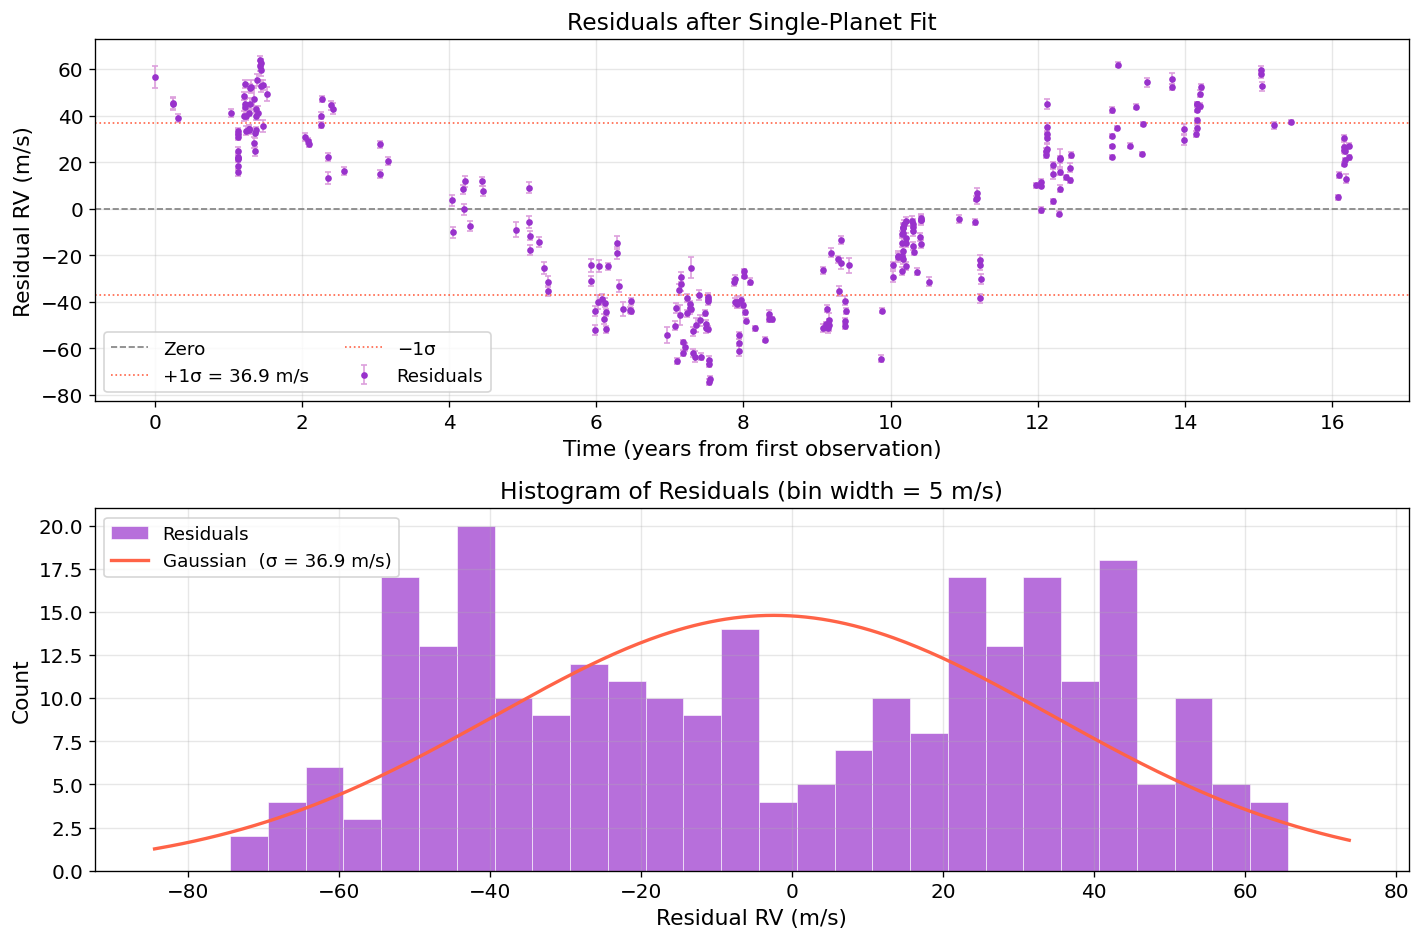

Figure saved as rv_residuals.png


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ── Top: residuals vs. time ──────────────────────────────────────────────────
ax = axes[0]
ax.errorbar(
    time / 365.25, residuals, yerr=rv_err,
    fmt='o', markersize=3, color='darkorchid',
    ecolor='plum', elinewidth=1, capsize=2,
    label='Residuals'
)
ax.axhline(0,  color='gray',  linewidth=1.0, linestyle='--', label='Zero')
ax.axhline( residual_std,  color='tomato', linewidth=1.0, linestyle=':',
            label=f'+1σ = {residual_std:.1f} m/s')
ax.axhline(-residual_std, color='tomato', linewidth=1.0, linestyle=':',
            label=f'−1σ')
ax.set_xlabel('Time (years from first observation)')
ax.set_ylabel('Residual RV (m/s)')
ax.set_title('Residuals after Single-Planet Fit')
ax.legend(ncol=2)

# ── Bottom: histogram of residuals ──────────────────────────────────────────
ax = axes[1]
bins = np.arange(residuals.min(), residuals.max() + 5, 5)   # 5 m/s bins
n, bins_out, _ = ax.hist(
    residuals, bins=bins, color='darkorchid', alpha=0.7,
    edgecolor='white', linewidth=0.5, label='Residuals'
)

# Overlay a Gaussian with the fitted std
x_g = np.linspace(residuals.min() - 10, residuals.max() + 10, 300)
bin_width = bins[1] - bins[0]
gauss = (len(residuals) * bin_width
         / (residual_std * np.sqrt(2 * np.pi))
         * np.exp(-0.5 * ((x_g - residual_mean) / residual_std)**2))
ax.plot(x_g, gauss, color='tomato', linewidth=2,
        label=f'Gaussian  (σ = {residual_std:.1f} m/s)')

ax.set_xlabel('Residual RV (m/s)')
ax.set_ylabel('Count')
ax.set_title('Histogram of Residuals (bin width = 5 m/s)')
ax.legend()

plt.tight_layout()
plt.savefig('rv_residuals.png', bbox_inches='tight')
plt.show()
print('Figure saved as rv_residuals.png')

## Step 5: Exoplanet Mass Calculation

In [20]:
# ── Exoplanet mass calculation ───────────────────────────────────────────────

M_star_solar = 0.905          # 55 Cnc stellar mass in solar masses
K_ms    = abs(K_fit)          # semi-amplitude in m/s
P_days  = abs(P_fit)          # period in days
P_years = P_days / 365.25     # period in years

# Mass formula (planet mass in Jupiter masses)
# M_p/M_Jup = (K / 28.4329) * (P/1yr)^(1/3) * (M_star/M_sun)^(2/3)
M_planet_Jup = (K_ms / 28.4329) * (P_years ** (1/3)) * (M_star_solar ** (2/3))

# Uncertainty propagation (first order)
dM_dK = M_planet_Jup / K_ms
dM_dP = M_planet_Jup / (3 * P_days)
M_planet_err = np.sqrt((dM_dK * K_err)**2 + (dM_dP * P_err)**2)

print('=' * 55)
print('  Exoplanet Mass Calculation — 55 Cancri')
print('=' * 55)
print(f'  Stellar mass M★    = {M_star_solar} M☉')
print(f'  Semi-amplitude K   = {K_ms:.2f} ± {K_err:.2f} m/s')
print(f'  Orbital period P   = {P_days:.4f} ± {P_err:.4f} days')
print(f'                     = {P_years:.5f} years')
print()
print(f'  Planet mass Mₚ     = {M_planet_Jup:.4f} ± {M_planet_err:.4f} M_Jup')
print()

# Compare to known value
print('Reference: 55 Cnc b has M sin i = 0.831 M_Jup (NASA Exoplanet Archive)')
print(f'Our result:                       {M_planet_Jup:.3f} M_Jup')
print()
print('Conclusion: The detected exoplanet is 55 Cancri b.')

  Exoplanet Mass Calculation — 55 Cancri
  Stellar mass M★    = 0.905 M☉
  Semi-amplitude K   = 74.49 ± 0.13 m/s
  Orbital period P   = 14.6515 ± 0.0000 days
                     = 0.04011 years

  Planet mass Mₚ     = 0.8391 ± 0.0014 M_Jup

Reference: 55 Cnc b has M sin i = 0.831 M_Jup (NASA Exoplanet Archive)
Our result:                       0.839 M_Jup

Conclusion: The detected exoplanet is 55 Cancri b.
